# Data and Functions

In [2]:
import joblib
import numpy as np
import pandas as pd
import pickle

from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    average_precision_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyClassifier
from copy import copy
import numpy as np
import joblib
import lightgbm as lgb
import pickle
import os
import joblib
from sklearn.exceptions import UndefinedMetricWarning
import warnings

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [17]:
def read_pickled_input_files(file_path: str):
    
    X_train_val = None
    y_train_val = None
    X_test = None
    y_test = None

    with open(file_path + "/x_train_val.pickle", "rb") as file:
        X_train_val = pickle.load(file)
    
    with open(file_path + "/y_train_val.pickle", "rb") as file:
        y_train_val = pickle.load(file)
    
    with open(file_path + "/x_test.pickle", "rb") as file:
        X_test = pickle.load(file)
    
    with open(file_path + "/y_test.pickle", "rb") as file:
        y_test = pickle.load(file)
    
    return X_train_val, X_test, y_train_val, y_test

def load_data(folder_path: str):
    
    X_train_val, X_test, y_train_val, y_test = read_pickled_input_files(folder_path)
    
    y_train_val.replace(to_replace='positive', value=1, inplace=True)
    y_train_val.replace(to_replace='negative', value=0, inplace=True)
    y_test.replace(to_replace='positive', value=1, inplace=True)
    y_test.replace(to_replace='negative', value=0, inplace=True)

    # scaling data
    normalized_df = copy(X_train_val)

    scaler = StandardScaler().set_output(transform="pandas")
    _ = scaler.fit_transform(normalized_df)

    normalized_x_test = copy(X_test)
    scaled_X_test = scaler.transform(normalized_x_test)
    
    print(f"shapes of data: {X_test.shape}, {y_test.shape}")
    
    return X_test, scaled_X_test, y_test

In [7]:
def precision_0(y, y_pred):
    returned_arr = precision_score(y_true=y, y_pred=y_pred, average=None)
    return returned_arr[0]

def precision_1(y, y_pred):
    returned_arr = precision_score(y_true=y, y_pred=y_pred, average=None)
    return returned_arr[1]

def recall_0(y, y_pred):
    returned_arr = recall_score(y_true=y, y_pred=y_pred, average=None)
    return returned_arr[0]

def recall_1(y, y_pred):
    returned_arr = recall_score(y_true=y, y_pred=y_pred, average=None)
    return returned_arr[1]

scorers_for_gridcv = {
    "accuracy_score": make_scorer(accuracy_score),
    "precision_0": make_scorer(precision_0, greater_is_better=True),
    "precision_1": make_scorer(precision_1, greater_is_better=True),
    "recall_0": make_scorer(recall_0, greater_is_better=True),
    "recall_1": make_scorer(recall_1, greater_is_better=True),
    "fbeta_score": make_scorer(fbeta_score, beta=0.5),
    "balanced_accuracy_score": make_scorer(balanced_accuracy_score),
    "average_precision_score": make_scorer(average_precision_score),
    "roc_auc": make_scorer(roc_auc_score)
}

def get_all_scores(y_real, y_pred, y_scores):
    accuracy = accuracy_score(y_real, y_pred)
    precision0 = precision_0(y_real, y_pred)
    precision1 = precision_1(y_real, y_pred)
    recall0 = recall_0(y_real, y_pred)
    recall1 = recall_1(y_real, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_real, y_pred)
    fbeta = fbeta_score(y_real, y_pred, beta=0.5)
    avg_precision = average_precision_score(y_real, y_scores)
    roc_auc = roc_auc_score(y_real, y_scores)

    return {
        "accuracy": accuracy,
        "precision0": precision0,
        "precision1": precision1,
        "recall0": recall0,
        "recall1": recall1,
        "balanced_accuracy": balanced_accuracy,
        "fbeta": fbeta,
        "avg_precision": avg_precision,
        "roc_auc": roc_auc
    }

def test_model(model, X_test, y_test):
    y_pred = model.predict(X_test.values)
    y_pred_proba = model.predict_proba(X_test.values)
    
    return get_all_scores(y_test, y_pred, y_pred_proba[:, 1])

def print_confusion_matrix(model, X_test, y_test):
    y_pred = model.predict(X_test.values)
    print(confusion_matrix(y_test, y_pred))
    return

def perform_all_tests(model, X_test, scaled_X_test, y_test):
    
    scaled_output = test_model(model, scaled_X_test, y_test)
    unscaled_output = test_model(model, X_test, y_test)
    print('Scaled output')
    print(scaled_output)
    print_confusion_matrix(model, scaled_X_test, y_test)
    print('------------------------')
    print('Unscaled output')
    print(unscaled_output)
    print_confusion_matrix(model, X_test, y_test)
    return

# AppendixRUN21v1 --> Grid Search with Segment dataset, with polynom_fit_SMOTE_poly and scaling, without Log-Norm

In [38]:
data_folder = "segment"
model_folder = "AppendixRUN21v1"

X_test, scaled_X_test, y_test = load_data(data_folder)

shapes of data: (347, 14), (347,)


In [39]:
logit_model = joblib.load(os.path.join(model_folder, "logit.joblib"))
perform_all_tests(logit_model, X_test, scaled_X_test, y_test)

Scaled output
{'accuracy': 1.0, 'precision0': 1.0, 'precision1': 1.0, 'recall0': 1.0, 'recall1': 1.0, 'balanced_accuracy': 1.0, 'fbeta': 1.0, 'avg_precision': 1.0000000000000002, 'roc_auc': 1.0}
[[298   0]
 [  0  49]]
------------------------
Unscaled output
{'accuracy': 0.8587896253602305, 'precision0': 0.8587896253602305, 'precision1': 0.0, 'recall0': 1.0, 'recall1': 0.0, 'balanced_accuracy': 0.5, 'fbeta': 0.0, 'avg_precision': 0.8555045699172809, 'roc_auc': 0.9702095603342009}
[[298   0]
 [ 49   0]]


In [40]:
dt_model = joblib.load(os.path.join(model_folder, "dt.joblib"))
perform_all_tests(dt_model, X_test, scaled_X_test, y_test)

Scaled output
{'accuracy': 0.9942363112391931, 'precision0': 0.9933333333333333, 'precision1': 1.0, 'recall0': 1.0, 'recall1': 0.9591836734693877, 'balanced_accuracy': 0.9795918367346939, 'fbeta': 0.9915611814345991, 'avg_precision': 0.9649473622301946, 'roc_auc': 0.9795233529653471}
[[298   0]
 [  2  47]]
------------------------
Unscaled output
{'accuracy': 0.8587896253602305, 'precision0': 0.8587896253602305, 'precision1': 0.0, 'recall0': 1.0, 'recall1': 0.0, 'balanced_accuracy': 0.5, 'fbeta': 0.0, 'avg_precision': 0.14121037463976946, 'roc_auc': 0.4983221476510067}
[[298   0]
 [ 49   0]]


In [42]:
rf_model = joblib.load(os.path.join(model_folder, "rf.joblib"))
perform_all_tests(rf_model, X_test, scaled_X_test, y_test)

Scaled output
{'accuracy': 0.9394812680115274, 'precision0': 0.9893992932862191, 'precision1': 0.71875, 'recall0': 0.9395973154362416, 'recall1': 0.9387755102040817, 'balanced_accuracy': 0.9391864128201617, 'fbeta': 0.7540983606557377, 'avg_precision': 0.9536688637904006, 'roc_auc': 0.9757567456512807}
[[280  18]
 [  3  46]]
------------------------
Unscaled output
{'accuracy': 0.8559077809798271, 'precision0': 0.8583815028901735, 'precision1': 0.0, 'recall0': 0.9966442953020134, 'recall1': 0.0, 'balanced_accuracy': 0.4983221476510067, 'fbeta': 0.0, 'avg_precision': 0.5247578858632791, 'roc_auc': 0.676140254759622}
[[297   1]
 [ 49   0]]


In [43]:
xgb_model = joblib.load(os.path.join(model_folder, "xgb.joblib"))
perform_all_tests(xgb_model, X_test, scaled_X_test, y_test)

Scaled output
{'accuracy': 0.9884726224783862, 'precision0': 1.0, 'precision1': 0.9245283018867925, 'recall0': 0.9865771812080537, 'recall1': 1.0, 'balanced_accuracy': 0.9932885906040269, 'fbeta': 0.9386973180076629, 'avg_precision': 0.9245283018867925, 'roc_auc': 0.9932885906040269}
[[294   4]
 [  0  49]]
------------------------
Unscaled output
{'accuracy': 0.8559077809798271, 'precision0': 0.8583815028901735, 'precision1': 0.0, 'recall0': 0.9966442953020134, 'recall1': 0.0, 'balanced_accuracy': 0.4983221476510067, 'fbeta': 0.0, 'avg_precision': 0.14121037463976946, 'roc_auc': 0.4983221476510067}
[[297   1]
 [ 49   0]]


# AppendixRUN22v1 --> Grid Search with Yeast1 dataset, with polynom_fit_SMOTE_poly and scaling, without Log-Norm

In [45]:
data_folder = "one_yeast"
model_folder = "AppendixRUN22v1"

X_test, scaled_X_test, y_test = load_data(data_folder)

shapes of data: (223, 8), (223,)


In [46]:
logit_model = joblib.load(os.path.join(model_folder, "logit.joblib"))
perform_all_tests(logit_model, X_test, scaled_X_test, y_test)

Scaled output
{'accuracy': 0.7354260089686099, 'precision0': 0.8551724137931035, 'precision1': 0.5128205128205128, 'recall0': 0.7654320987654321, 'recall1': 0.6557377049180327, 'balanced_accuracy': 0.7105849018417324, 'fbeta': 0.5361930294906166, 'avg_precision': 0.5584413532809319, 'roc_auc': 0.784254199554746}
[[124  38]
 [ 21  40]]
------------------------
Unscaled output
{'accuracy': 0.7399103139013453, 'precision0': 0.7524271844660194, 'precision1': 0.5882352941176471, 'recall0': 0.9567901234567902, 'recall1': 0.16393442622950818, 'balanced_accuracy': 0.5603622748431492, 'fbeta': 0.3875968992248062, 'avg_precision': 0.5520242312551922, 'roc_auc': 0.7818255413883829}
[[155   7]
 [ 51  10]]


In [47]:
dt_model = joblib.load(os.path.join(model_folder, "dt.joblib"))
perform_all_tests(dt_model, X_test, scaled_X_test, y_test)

Scaled output
{'accuracy': 0.7488789237668162, 'precision0': 0.7731958762886598, 'precision1': 0.5862068965517241, 'recall0': 0.9259259259259259, 'recall1': 0.2786885245901639, 'balanced_accuracy': 0.6023072252580449, 'fbeta': 0.480225988700565, 'avg_precision': 0.4242503132760606, 'roc_auc': 0.6990487755515078}
[[150  12]
 [ 44  17]]
------------------------
Unscaled output
{'accuracy': 0.27802690582959644, 'precision0': 1.0, 'precision1': 0.2747747747747748, 'recall0': 0.006172839506172839, 'recall1': 1.0, 'balanced_accuracy': 0.5030864197530864, 'fbeta': 0.321390937829294, 'avg_precision': 0.2747747747747748, 'roc_auc': 0.5030864197530864}
[[  1 161]
 [  0  61]]


In [48]:
rf_model = joblib.load(os.path.join(model_folder, "rf.joblib"))
perform_all_tests(rf_model, X_test, scaled_X_test, y_test)

Scaled output
{'accuracy': 0.7443946188340808, 'precision0': 0.7900552486187845, 'precision1': 0.5476190476190477, 'recall0': 0.8827160493827161, 'recall1': 0.3770491803278688, 'balanced_accuracy': 0.6298826148552925, 'fbeta': 0.5021834061135371, 'avg_precision': 0.559433442405729, 'roc_auc': 0.7550597045132563}
[[143  19]
 [ 38  23]]
------------------------
Unscaled output
{'accuracy': 0.4125560538116592, 'precision0': 0.918918918918919, 'precision1': 0.3118279569892473, 'recall0': 0.20987654320987653, 'recall1': 0.9508196721311475, 'balanced_accuracy': 0.580348107670512, 'fbeta': 0.36024844720496896, 'avg_precision': 0.36821721173458755, 'roc_auc': 0.642481279093301}
[[ 34 128]
 [  3  58]]


In [49]:
xgb_model = joblib.load(os.path.join(model_folder, "xgb.joblib"))
perform_all_tests(xgb_model, X_test, scaled_X_test, y_test)

Scaled output
{'accuracy': 0.7847533632286996, 'precision0': 0.85625, 'precision1': 0.6031746031746031, 'recall0': 0.845679012345679, 'recall1': 0.6229508196721312, 'balanced_accuracy': 0.7343149160089051, 'fbeta': 0.6070287539936102, 'avg_precision': 0.47888712690594626, 'roc_auc': 0.7343149160089051}
[[137  25]
 [ 23  38]]
------------------------
Unscaled output
{'accuracy': 0.32286995515695066, 'precision0': 1.0, 'precision1': 0.28773584905660377, 'recall0': 0.06790123456790123, 'recall1': 1.0, 'balanced_accuracy': 0.5339506172839507, 'fbeta': 0.3355335533553355, 'avg_precision': 0.28773584905660377, 'roc_auc': 0.5339506172839505}
[[ 11 151]
 [  0  61]]


# AppendixRUN23v1 --> Grid Search with Yeast3 dataset, with polynom_fit_SMOTE_poly and scaling, without Log-Norm

In [50]:
data_folder = "three_yeast"
model_folder = "AppendixRUN23v1"

X_test, scaled_X_test, y_test = load_data(data_folder)

shapes of data: (223, 8), (223,)


In [51]:
logit_model = joblib.load(os.path.join(model_folder, "logit.joblib"))
perform_all_tests(logit_model, X_test, scaled_X_test, y_test)

Scaled output
{'accuracy': 0.9237668161434978, 'precision0': 0.9786096256684492, 'precision1': 0.6388888888888888, 'recall0': 0.9336734693877551, 'recall1': 0.8518518518518519, 'balanced_accuracy': 0.8927626606198035, 'fbeta': 0.672514619883041, 'avg_precision': 0.7921177815948828, 'roc_auc': 0.9663643235071806}
[[183  13]
 [  4  23]]
------------------------
Unscaled output
{'accuracy': 0.8789237668161435, 'precision0': 0.8789237668161435, 'precision1': 0.0, 'recall0': 1.0, 'recall1': 0.0, 'balanced_accuracy': 0.5, 'fbeta': 0.0, 'avg_precision': 0.7966450968373975, 'roc_auc': 0.9671201814058956}
[[196   0]
 [ 27   0]]


In [52]:
dt_model = joblib.load(os.path.join(model_folder, "dt.joblib"))
perform_all_tests(dt_model, X_test, scaled_X_test, y_test)

Scaled output
{'accuracy': 0.9506726457399103, 'precision0': 0.9556650246305419, 'precision1': 0.9, 'recall0': 0.9897959183673469, 'recall1': 0.6666666666666666, 'balanced_accuracy': 0.8282312925170068, 'fbeta': 0.8411214953271028, 'avg_precision': 0.7491067638925137, 'roc_auc': 0.9349017384731672}
[[194   2]
 [  9  18]]
------------------------
Unscaled output
{'accuracy': 0.8789237668161435, 'precision0': 0.8789237668161435, 'precision1': 0.0, 'recall0': 1.0, 'recall1': 0.0, 'balanced_accuracy': 0.5, 'fbeta': 0.0, 'avg_precision': 0.1210762331838565, 'roc_auc': 0.5}
[[196   0]
 [ 27   0]]


In [53]:
rf_model = joblib.load(os.path.join(model_folder, "rf.joblib"))
perform_all_tests(rf_model, X_test, scaled_X_test, y_test)

Scaled output
{'accuracy': 0.9192825112107623, 'precision0': 0.9494949494949495, 'precision1': 0.68, 'recall0': 0.9591836734693877, 'recall1': 0.6296296296296297, 'balanced_accuracy': 0.7944066515495087, 'fbeta': 0.6692913385826772, 'avg_precision': 0.6930288096377661, 'roc_auc': 0.8875661375661377}
[[188   8]
 [ 10  17]]
------------------------
Unscaled output
{'accuracy': 0.852017937219731, 'precision0': 0.8899521531100478, 'precision1': 0.2857142857142857, 'recall0': 0.9489795918367347, 'recall1': 0.14814814814814814, 'balanced_accuracy': 0.5485638699924414, 'fbeta': 0.24096385542168675, 'avg_precision': 0.1900329282682224, 'roc_auc': 0.6532501889644747}
[[186  10]
 [ 23   4]]


In [54]:
xgb_model = joblib.load(os.path.join(model_folder, "xgb.joblib"))
perform_all_tests(xgb_model, X_test, scaled_X_test, y_test)

Scaled output
{'accuracy': 0.9327354260089686, 'precision0': 0.9547738693467337, 'precision1': 0.75, 'recall0': 0.9693877551020408, 'recall1': 0.6666666666666666, 'balanced_accuracy': 0.8180272108843537, 'fbeta': 0.7317073170731707, 'avg_precision': 0.5403587443946188, 'roc_auc': 0.8180272108843537}
[[190   6]
 [  9  18]]
------------------------
Unscaled output
{'accuracy': 0.8789237668161435, 'precision0': 0.8789237668161435, 'precision1': 0.0, 'recall0': 1.0, 'recall1': 0.0, 'balanced_accuracy': 0.5, 'fbeta': 0.0, 'avg_precision': 0.1210762331838565, 'roc_auc': 0.5}
[[196   0]
 [ 27   0]]


ImportError: You must install graphviz to plot tree

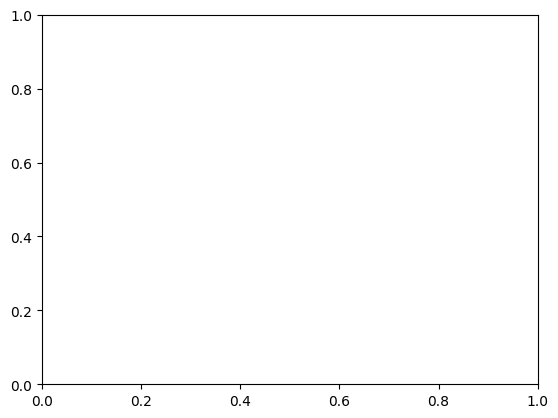

In [56]:
xgb.plot_tree(xgb_model)

# Glossary for experiment names

name --> meaning

RQ2RUN1 --> 

In [62]:
import pandas as pd

df = pd.read_csv('lgb_cv_result_epoch_5.csv')
df.sort_values(by="rank_test_" + 'average_precision_score', ascending=True, inplace=True)


In [66]:
df[[x for x in df.columns if x.find('param_') >=0]+['rank_test_average_precision_score']].to_csv('output.csv', index=False)

In [ ]:
lgbm 

num_leaves, steps of 25 from 50 to 200 
min_data_in_leaf, steps of 5 from 10 to 50
max_depth, steps of 10 from 20 to 100
num_iterations[n_estimator] 30 to 100, steps of 10
learning_rate: [0.01, 0.05, 0.1]
early_stopping_round 0, 1, 5, 10
subsample: .6 to .8 steps of .05, and 1.0 
reg_lambda: 0.0, .001, 0.01,  0.1


In [ ]:
xgb
objective binary:logistic, binary:hinge
max_leaves, steps of 25 from 50 to 200 
min_child_weight, steps of 5 from 10 to 50
max_depth, steps of 10 from 20 to 100
num_iterations[n_estimator] 30 to 100, steps of 10
learning_rate: [0.01, 0.05, 0.1]
early_stopping_round 0, 1, 5, 10
subsample: .6 to .8 steps of .05, and 1.0 
reg_lambda: 0.0, .001, 0.01,  0.1


In [ ]:
rf
min_samples_split: 50 to 300, steps of 50
min_samples_leaf: steps of 5 from 10 to 50
criterion{gini, log_loss},
max_leaf_nodes: steps of 25 from 50 to 200,
min_impurity_decrease: 0, 0.1, 0.05, 0.2

In [ ]:
max_iter: 50, 100, 200, 500


# Final Go

In [1]:
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    average_precision_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from copy import copy

def get_all_scores(y_real, y_pred, y_scores):
    accuracy = accuracy_score(y_real, y_pred)
    precision = precision_score(y_real, y_pred, average=None)
    recall = recall_score(y_real, y_pred, average=None)
    balanced_accuracy = balanced_accuracy_score(y_real, y_pred)
    fbeta = fbeta_score(y_real, y_pred, beta=0.5)
    avg_precision = average_precision_score(y_real, y_scores)
    roc_auc = roc_auc_score(y_real, y_scores)

    return {
        "average_precision": round(avg_precision, 2), 
        "precision_0": round(precision[0], 2), 
        "precision_1": round(precision[1], 2), 
        "recall_0": round(recall[0], 2), 
        "recall_1": round(recall[1], 2), 
        "roc_auc": round(roc_auc, 2),
        "balanced_accuracy": round(balanced_accuracy, 2),
        "fbeta": round(fbeta, 2), 
        "accuracy": round(accuracy, 2), 
    }

def flip_true_false(y):
    copy_y = copy(y)
    flipped_y = [0 if item == 1 else 1 for item in copy_y]
    return flipped_y

def test_model(model, scaled_X_test_df, y_test):
    y_pred = model.predict(scaled_X_test_df)
    y_pred_proba = model.predict_proba(scaled_X_test_df)
    
    return get_all_scores(y_test, y_pred, y_pred_proba[:, 1])

    # flipped_y = flip_true_false(y_pred)
    # print(get_all_scores(y_test, flipped_y, y_pred_proba[:, 0]))
    

In [2]:
# accuracy, precision, recall, balanced_accuracy, fbeta, avg_precision, roc_auc
import joblib
import pandas as pd

def performance_testing(project, scaled_X_test_df, y_test):

    logit_model = joblib.load(f'./{project}/Logistic-Model-v0/logit.joblib')
    logit_scores = test_model(logit_model, scaled_X_test_df, y_test)

    dt_model = joblib.load(f'./{project}/DT-Model-v0/dt.joblib')
    dt_scores = test_model(dt_model, scaled_X_test_df, y_test)

    rf_model = joblib.load(f'./{project}/RF-Model-v0/rf.joblib')
    rf_scores = test_model(rf_model, scaled_X_test_df, y_test)

    xgb_model = joblib.load(f'./{project}/XGB-Model-v0/xgb.joblib')
    xgb_scores = test_model(xgb_model, scaled_X_test_df, y_test)

    lgb_model = joblib.load(f'./{project}/LGB-Model-v0/lgb.joblib')
    lgb_scores = test_model(lgb_model, scaled_X_test_df, y_test)
    
    default_rf_model = joblib.load(f'./{project}/Default-RF-Cls-v0/default_rf.joblib')
    default_rf_scores = test_model(default_rf_model, scaled_X_test_df, y_test)

    freq_dummy_model = joblib.load(f'./{project}/Most-Freq-Dummy-Cls-v0/most_freq_dummy_cls.joblib')
    freq_dummy_scores = test_model(freq_dummy_model, scaled_X_test_df, y_test)

    stratified_dummy_model = joblib.load(f'./{project}/Stratified-Dummy-Cls-v0/stratified_dummy_cls.joblib')
    stratified_dummy_scores = test_model(stratified_dummy_model, scaled_X_test_df, y_test)

    # result_df = pd.DataFrame(
    #     [
    #     logit_scores, dt_scores, rf_scores, xgb_scores, lgb_scores, default_rf_scores, stratified_dummy_scores, freq_dummy_scores
    #     ],
    #     index=['logit_scores', 'dt_scores', 'rf_scores', 'xgb_scores', 'lgb_scores', 'default_rf_scores', 'stratified_dummy_scores', 'freq_dummy_scores']
    # )
    
    result_df = pd.DataFrame(
        [
        logit_scores, dt_scores, rf_scores, xgb_scores, lgb_scores, stratified_dummy_scores, freq_dummy_scores        ],
        index=['logit_scores', 'dt_scores', 'rf_scores', 'xgb_scores', 'lgb_scores', 'stratified_dummy_scores', 'freq_dummy_scores']
    )

    # return result_df.sort_values(by='average_precision', ascending=False)
    return result_df

In [4]:
def best_performing_model(project, result_df):
    model = None
    
    res = result_df.sort_values(by='average_precision', ascending=False)
    names = ['logit_scores', 'dt_scores', 'rf_scores', 'lgb_scores', 'xgb_scores', 'default_rf_scores', 'freq_dummy_scores', 'stratified_dummy_scores']
    if res.iloc[0].name == 'logit_scores':
        model = joblib.load(f'./{project}/Logistic-Model-v0/logit.joblib')
    elif res.iloc[0].name == 'dt_scores':
        model = joblib.load(f'./{project}/DT-Model-v0/dt.joblib')
    elif res.iloc[0].name == 'rf_scores':
        model = joblib.load(f'./{project}/RF-Model-v0/rf.joblib')
    elif res.iloc[0].name == 'lgb_scores':
        model = joblib.load(f'./{project}/LGB-Model-v0/lgb.joblib')
    elif res.iloc[0].name == 'xgb_scores':
        model = joblib.load(f'./{project}/XGB-Model-v0/xgb.joblib')
    elif res.iloc[0].name == 'default_rf_scores':
        model = joblib.load(f'./{project}/Default-RF-Cls-v0/default_rf.joblib')
    elif res.iloc[0].name == 'freq_dummy_scores':
        model = joblib.load(f'./{project}/Most-Freq-Dummy-Cls-v0/most_freq_dummy_cls.joblib')
    elif res.iloc[0].name == 'stratified_dummy_scores':
        model = joblib.load(f'./{project}/Stratified-Dummy-Cls-v0/stratified_dummy_cls.joblib')
    
    freq_model = joblib.load(f'./{project}/Most-Freq-Dummy-Cls-v0/most_freq_dummy_cls.joblib')
    strat_model = joblib.load(f'./{project}/Stratified-Dummy-Cls-v0/stratified_dummy_cls.joblib')
    return model, freq_model, strat_model

# logit_predict_proba = logit_model.predict_proba(scaled_X_test_df)

In [5]:
from copy import copy
import pickle
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

def read_pickled_data(dataset, order, dropped_columns, feature_selection):

    with open(dataset + '/x_train_val.pickle', "rb") as file:
        X_train_val = pickle.load(file)

    with open(dataset + '/y_train_val.pickle' , "rb") as file:
        y_train_val = pickle.load(file)

    with open(dataset + '/x_test.pickle',  "rb") as file:
        X_test = pickle.load(file)

    with open(dataset + '/y_test.pickle',  "rb") as file:
        y_test = pickle.load(file)
    
    if feature_selection == 1:
        order = [item for item in order if item not in dropped_columns]
        X_train_val.drop(dropped_columns, axis=1, inplace=True)
        X_test.drop(dropped_columns, axis=1, inplace=True)
    
    normalized_df = copy(X_train_val)
    
    scaler = StandardScaler()

    preprocessor = ColumnTransformer([
        ('scale', scaler, list(X_train_val.columns))
    ], verbose_feature_names_out=False)
        
    scaled_X_train_val = preprocessor.fit_transform(normalized_df)
    scaled_X_test = preprocessor.transform(X_test)

    transformed_columns = list(preprocessor.get_feature_names_out())
    
    scaled_X_train_val_df = pd.DataFrame(scaled_X_train_val, columns=transformed_columns)
    scaled_X_test_df = pd.DataFrame(scaled_X_test, columns=transformed_columns)
    
    scaled_X_train_val_df =  scaled_X_train_val_df[order]
    scaled_X_test_df =  scaled_X_test_df[order]

    return scaled_X_train_val_df, y_train_val, scaled_X_test_df, y_test


In [6]:
configuration = {
    'Appendix1_folder': 'one_yeast',
    'Appendix2_folder': 'three_yeast',
    'Appendix3_folder': 'shuttle',
    'Appendix4_folder': 'segment',
    
    'Appendix1_drop': ['Erl'],
    'Appendix2_drop': ['Nuc'],
    'Appendix3_drop': ['A7', 'A8', 'A9'],
    'Appendix4_drop': ['Intensity-mean', 'Rawgreen-mean', 'Rawblue-mean', 'Exblue-mean', 'Value-mean', 'Region-pixel-count'],
    
    'Appendix1_order': ['Mcg', 'Gvh', 'Alm', 'Mit', 'Pox', 'Vac', 'Nuc'],
    'Appendix2_order': ['Mcg', 'Gvh', 'Alm', 'Mit', 'Erl', 'Pox', 'Vac'],
    'Appendix3_order': ['A1', 'A2', 'A3', 'A4', 'A5', 'A6'],
    'Appendix4_order': ['Region-centroid-col', 'Region-centroid-row', 'Short-line-density-5', 'Short-line-density-2', 'Vedge-mean', 'Vegde-sd', 'Hedge-mean', 'Hedge-sd', 'Rawred-mean', 'Exred-mean', 'Exgreen-mean', 'Saturatoin-mean', 'Hue-mean']
}

In [26]:
folder="Appendix4"
folder_path = configuration[f'{folder}_folder'] # change it for RQ2Final1, RQ2Final2
removed_columns = configuration[f'{folder}_drop']
order = configuration[f'{folder}_order']
print(folder_path)
scaled_X_train_val, y_train_val, scaled_X_test, y_test = read_pickled_data(folder_path, order, removed_columns, 1)
print(scaled_X_train_val.shape, y_train_val.shape, scaled_X_test.shape, y_test.shape)
result_df = performance_testing(folder_path, scaled_X_test, y_test)
best_model, freq_model, strat_model = best_performing_model(folder_path, result_df)
# result_df.sort_values(by='average_precision', ascending=False, inplace=True)
result_df[['average_precision', 'roc_auc', 'balanced_accuracy', 'precision_0', 'precision_1', 'recall_0', 'recall_1']]

segment
(2077, 13) (2077,) (231, 13) (231,)


c:\Program Files\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,average_precision,roc_auc,balanced_accuracy,precision_0,precision_1,recall_0,recall_1
logit_scores,1.00,1.00,1.00,1.00,1.00,1.00,1.00
dt_scores,0.92,0.97,0.97,0.99,0.97,0.99,0.94
rf_scores,0.98,1.00,0.97,0.99,0.97,0.99,0.94
xgb_scores,0.97,0.98,0.98,0.99,1.00,1.00,0.97
lgb_scores,1.00,1.00,0.98,0.99,1.00,1.00,0.97
stratified_dummy_scores,0.14,0.48,0.50,0.86,0.14,0.48,0.52
freq_dummy_scores,0.14,0.50,0.50,0.86,0.00,1.00,0.00


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

label = 1

# best_model, freq_model, strat_model 

best_predict_proba = best_model.predict_proba(scaled_X_test)
freq_dummy_predict_proba = freq_model.predict_proba(scaled_X_test)
strat_predict_proba = strat_model.predict_proba(scaled_X_test)

best_precision, best_recall, _ = precision_recall_curve(y_test, best_predict_proba[:, label])
most_freq_precision, most_freq_recall, _ = precision_recall_curve(y_test, freq_dummy_predict_proba[:, label])
stratified_precision, stratified_recall, _ = precision_recall_curve(y_test, strat_predict_proba[:, label])

no_skill = len(y_test[y_test==label]) / len(y_test)

colors = ['black', 'red', 'lime', 'dodgerblue', 'yellow', 'navy', 'cyan']

# Plot each model's Precision-Recall curve on the same axes
plt.figure(figsize=(8, 6))
lgb_display = PrecisionRecallDisplay(precision=best_precision, recall=best_recall)
lgb_display.plot(label="LGB", color=colors[0], ax=plt.gca())  # plt.gca() gets current axes

freq_display = PrecisionRecallDisplay(precision=most_freq_precision, recall=most_freq_recall)
freq_display.plot(label="Most Frequent", color=colors[1], ax=plt.gca())  # plt.gca() gets current axes

stratified_display = PrecisionRecallDisplay(precision=stratified_precision, recall=stratified_recall)
stratified_display.plot(label="Stratified", color=colors[6], ax=plt.gca())  # plt.gca() gets current axes

plt.gca().plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')

# Add labels and legend
# plt.title("Comparison of Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
# plt.show()

plt.savefig(f'./{folder}/' + f'{folder}-pr-curve.pdf', format='pdf', bbox_inches='tight')